# EfficientNetB0 Evaluation & Predictions

This notebook loads the trained **EfficientNetB0** model for pneumonia detection (normal / bacteria / virus),
rebuilds the DataLoaders via `on_the_fly_augmentation.ipynb`, then computes metrics on the **test set** and shows a few predictions.

We use the same tools as in training:
- **PyTorch** for the model and DataLoaders,
- **EfficientNetB0** from `torchvision` as the backbone architecture,
- the loss function and `scikit-learn` metrics to analyze model performance.

The goal is to compute several classification metrics (Accuracy, Precision, Recall, F1-score, ROC-AUC) and visualize them as a **bar chart**.

c:\Users\belli\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Users\belli\AppData\Local\Programs\Python\Python313\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


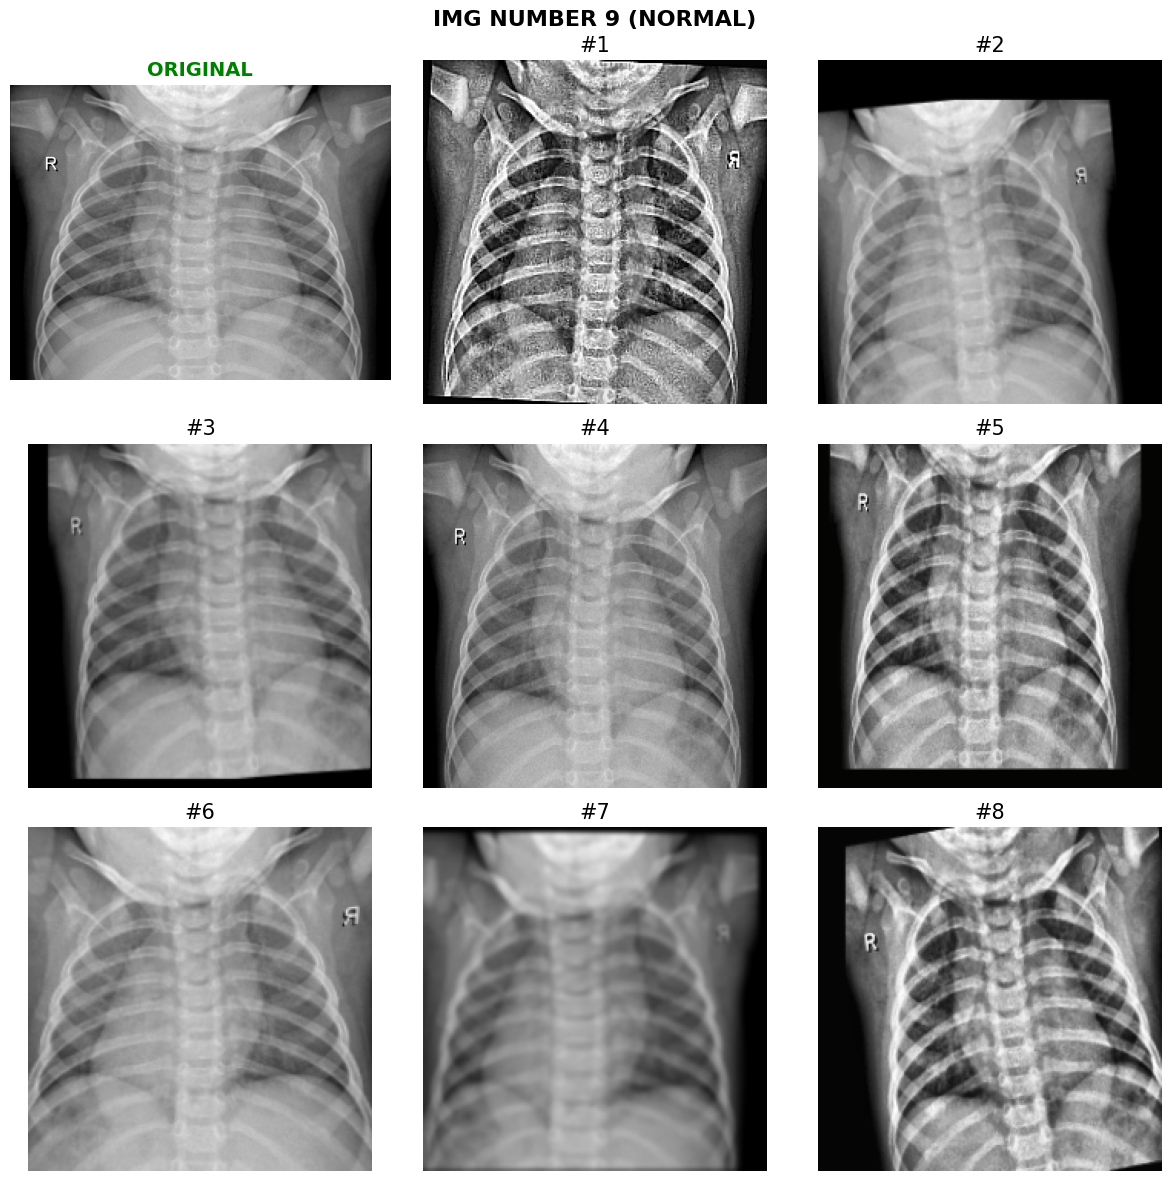


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [0, 0, 1, 1, 0, 1, 2, 1, 1, 2]
Label distribution: [9, 17, 6]


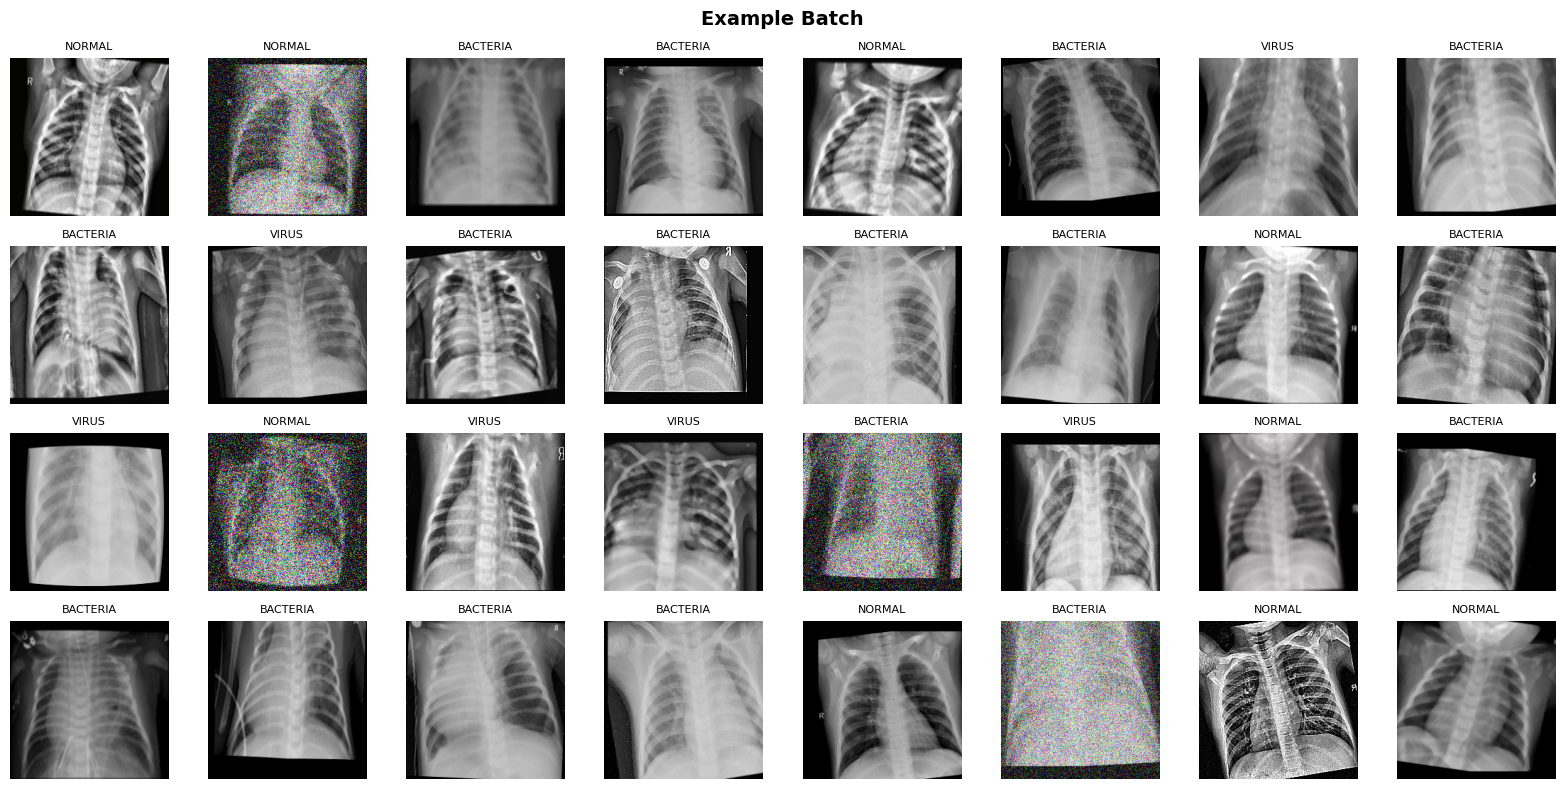

In [ ]:
# Reload the augmentation pipeline and DataLoaders
# This runs the augmentation notebook to recreate `test_loader`
%run "../../prepocessing.ipynb"

## 1. Rebuilding the model and loading weights

We rebuild the exact same **EfficientNetB0** architecture as in the training notebook:

- same number of classes (3),
- same replacement of the final classification layer,
- same initialization from an ImageNet-pretrained backbone.

Then we load the learned weights (`efficientnet_b0_pneumonia.pt`) and set the model to `eval()` mode to freeze behavior during evaluation.

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

NUM_CLASSES = 3
class_names = ["normal", "bacteria", "virus"]

# Rebuild the model and reload weights
weights = EfficientNet_B0_Weights.IMAGENET1K_V1
model = efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

model_path = "./efficientnet_b0_TL_pneumonia.pt"
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f"Weights loaded from {model_path}")

Using device: cpu
Weights loaded from ./efficientnet_b0_pneumonia.pt



Classification report (per class):
              precision    recall  f1-score   support

      normal       0.97      0.85      0.90       234
    bacteria       0.84      0.96      0.90       242
       virus       0.78      0.76      0.77       148

    accuracy                           0.87       624
   macro avg       0.86      0.86      0.86       624
weighted avg       0.88      0.87      0.87       624


Global metrics (macro-average):
Accuracy  : 0.8702
Precision : 0.8645
Recall    : 0.8561
F1-score  : 0.8576
ROC-AUC   : 0.9646


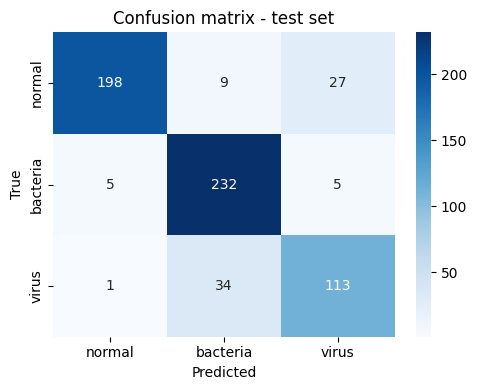

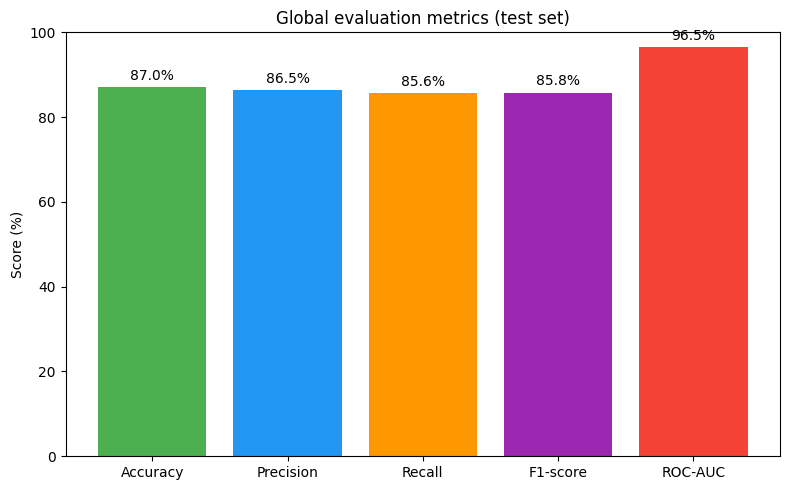

In [4]:
# Evaluation on the test set
# Metrics computed here: Accuracy, Precision, Recall, F1-score, and ROC-AUC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

all_labels = []
all_preds = []
all_probs = []  # softmax probabilities needed for ROC-AUC

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Global metrics (macro-average for per-class balancing)
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

# Multiclass ROC-AUC (one-vs-rest)
try:
    roc_auc = roc_auc_score(all_labels, all_probs, multi_class="ovr")
except ValueError:
    roc_auc = float("nan")

print("\nClassification report (per class):")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nGlobal metrics (macro-average):")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix - test set")
plt.tight_layout()
plt.show()

# Bar chart of metrics (percentage)
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
metrics_values = [accuracy, precision, recall, f1, roc_auc]

# Convert to percentage
metrics_percent = [m * 100 for m in metrics_values]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, metrics_percent, color=["#4caf50", "#2196f3", "#ff9800", "#9c27b0", "#f44336"])
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.title("Global evaluation metrics (test set)")
for i, v in enumerate(metrics_percent):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 2. Qualitative visualization of a few predictions

To complement the global metrics, we display a few test-set images with:

- the **true label**,
- the **model prediction**.

This makes it easier to visually inspect the model behavior on concrete examples (including potential mistakes).

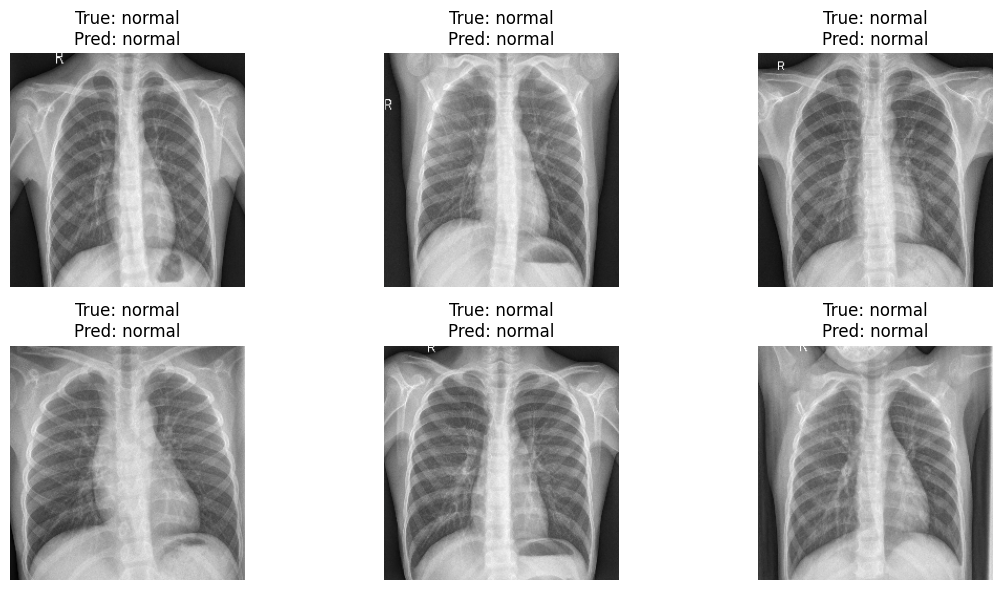

In [5]:
# Visualize a few predictions

num_examples = 6
shown = 0

plt.figure(figsize=(12, 6))

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(images.size(0)):
            if shown >= num_examples:
                break

            img = images[i].cpu().numpy().transpose(1, 2, 0)
            # Roughly invert ImageNet normalization
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = np.clip(img, 0, 1)

            true_label = class_names[labels[i].item()]
            pred_label = class_names[preds[i].item()]

            plt.subplot(2, 3, shown + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"True: {true_label}\nPred: {pred_label}")

            shown += 1
        if shown >= num_examples:
            break

plt.tight_layout()
plt.show()